# States III: real-space states (local density of states)
Instead of asking "how many states at energy $E$" (DOS) or "what is $\epsilon_k$" (bands), the local density of states asks *where in real space* a state at energy $E$ lives:
$$ \rho_i(E) = -\frac{1}{\pi}\,\mathrm{Im}\,G_{ii}(E),\qquad G(E) = \big[(E+i\delta)\mathbb{1} - H\big]^{-1} $$
This is the natural tool for finite systems (islands, flakes) where edges and corners can host states that do not exist in the bulk. We use a triangular zigzag-edged honeycomb island, known to host zero-energy edge states protected by the sublattice imbalance between its two edges.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import islands
from pyqula.ldos import ldos0d

### Build a triangular zigzag-edge honeycomb island

In [2]:
g = islands.get_geometry(name="honeycomb",n=4,nedges=3) # triangular flake
h = g.get_hamiltonian()
print("number of sites:", len(g.r))

number of sites: 141


### LDOS at zero energy vs. deep in the band
`ldos0d` diagonalizes the finite Hamiltonian directly and returns $\rho_i(E)$ per site (`write=False` keeps the result in memory instead of writing a file).

At $E=0$ the zero modes live *only* on the majority sublattice (a consequence of chiral/bipartite symmetry), so the minority sublattice sites show exactly zero LDOS — the checkerboard pattern below is that selection rule, not noise — and among the majority-sublattice sites the weight is largest on the edge and decays into the bulk.

In [3]:
d_edge = ldos0d(h, e=0.0, delta=0.05, write=False)  # near the Fermi level
d_bulk = ldos0d(h, e=2.5, delta=0.10, write=False)  # deep inside the band

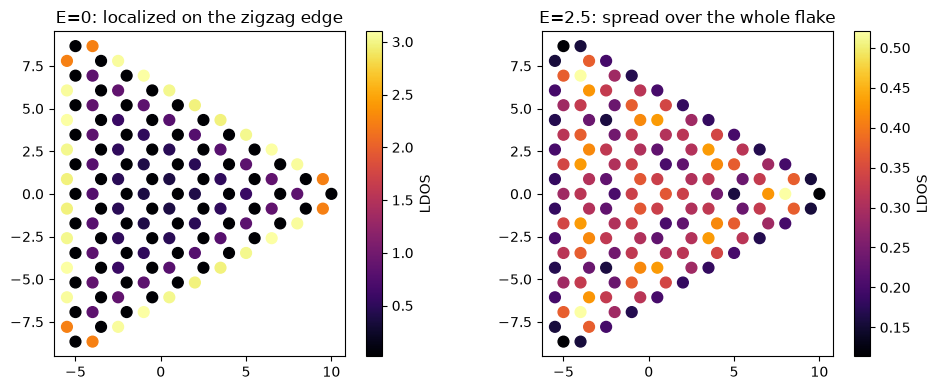

In [4]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

s0 = axes[0].scatter(g.x, g.y, c=d_edge, cmap="inferno", s=60)
axes[0].set_title("E=0: localized on the zigzag edge")
axes[0].set_aspect("equal")
plt.colorbar(s0, ax=axes[0], label="LDOS")

s1 = axes[1].scatter(g.x, g.y, c=d_bulk, cmap="inferno", s=60)
axes[1].set_title("E=2.5: spread over the whole flake")
axes[1].set_aspect("equal")
plt.colorbar(s1, ax=axes[1], label="LDOS")

plt.tight_layout()
plt.show()